In [1]:

# pip install opencv-python
# pip install numpy
# pip install scikit-image


Áreas foliares em cm²:
Folha 1: 49.451163458776215 cm²
Folha 2: 45.0063200229819 cm²
Folha 3: 15.886814133869578 cm²
Folha 4: 44.39974145360529 cm²
Folha 5: 43.38746049985637 cm²


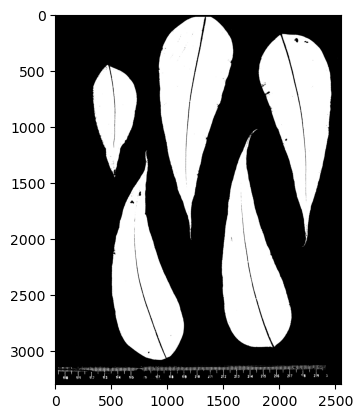

In [2]:
import cv2
#import numpy as np
from skimage.measure import label, regionprops
import matplotlib.pyplot as plt

# Carregando a imagem e convertendo para escala de cinza
imagem = cv2.imread('../exemplos/Digitalizadas/Fazenda_Exemplo_01/A1_I.1.jpg')
imagem_cinza = cv2.cvtColor(imagem, cv2.COLOR_BGR2GRAY)

# invertendo mascara onde as areas com valores 0 sera o fundo branco 
imagem_cinza = 255 - imagem_cinza

# Binarizando a imagem
limiar = 150  # Defina um limiar adequado para a sua imagem
imagem_binaria = cv2.threshold(imagem_cinza, limiar, 252, cv2.THRESH_BINARY)[1]

# plotando imagem mascarada, onde 0 descarta e 1 sera computada a area foliar
plt.imshow(imagem_binaria, cmap='gray')

# Removendo ruídos
imagem_binaria = cv2.morphologyEx(imagem_binaria, cv2.MORPH_OPEN, cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (30, 30)))

# Rotulando as regiões de interesse
rotulos = label(imagem_binaria, connectivity=2)

# Calculando a área de cada região (folha)
props = regionprops(rotulos)
areas = [prop.area for prop in props]

# Convertendo as áreas de pixels para cm²
comprimento_régua_cm = 1  # Defina o comprimento da régua em cm
comprimento_régua_pixels = 118  # Meça o comprimento da régua em pixels na imagem
fator_conversão = (comprimento_régua_cm ** 2) / (comprimento_régua_pixels ** 2)
areas_cm2 = [area * fator_conversão for area in areas]

print('Áreas foliares em cm²:')
for i, area in enumerate(areas_cm2, start=1):
    # condicao para eliminar o ruído da régua (< 1 cm²)
    if area<1:
        pass
    else:
        print(f'Folha {i}: {area} cm²')

In [3]:
imagem

array([[[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       ...,

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [255, 255, 255]]